In [1]:
!pip install biotite

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic


In [2]:
import numpy as np

import biotite.structure.io.pdbx as pdbx

cif_path = "output/test_tiny/seed_101/predictions/test_tiny_sample_0.cif"
cif_file = pdbx.CIFFile.read(cif_path)
structure = pdbx.get_structure(cif_file, model=1)

In [3]:
type(structure)

biotite.structure.AtomArray

In [4]:
print(structure[:5])

print(structure.get_annotation_categories())

    A       1  MET N      N        -7.254   -3.263   -9.594
    A       1  MET CA     C        -7.112   -3.644   -9.800
    A       1  MET C      C        -6.069   -2.594   -9.604
    A       1  MET O      O        -5.666   -1.873  -10.379
    A       1  MET CB     C        -7.891   -4.644   -9.951
['chain_id', 'res_id', 'ins_code', 'res_name', 'hetero', 'atom_name', 'element']


In [5]:
print(list(cif_file.keys()))

['test_tiny_sample_0_predicted_by_protenix']


In [6]:
block = cif_file['test_tiny_sample_0_predicted_by_protenix']
print(list(block.keys()))
print(list(block['atom_site'].keys()))

['entry', 'chem_comp', 'entity', 'entity_poly', 'entity_poly_seq', 'atom_site']
['group_PDB', 'type_symbol', 'label_atom_id', 'label_alt_id', 'label_comp_id', 'label_asym_id', 'label_entity_id', 'label_seq_id', 'pdbx_PDB_ins_code', 'auth_seq_id', 'auth_comp_id', 'auth_asym_id', 'auth_atom_id', 'B_iso_or_equiv', 'Cartn_x', 'Cartn_y', 'Cartn_z', 'pdbx_PDB_model_num', 'id', 'occupancy']


In [7]:
b_factors = block['atom_site']['B_iso_or_equiv'].as_array(float)
print(b_factors[:10])

[33.69 31.63 34.77 33.05 33.13 31.18 30.11 28.99 37.1  34.93]


In [8]:
len(b_factors)

1282

In [9]:
atom_ids = block['atom_site']['label_atom_id']
atom_ids.data.array[:10]

# Alternatively
atom_ids = block['atom_site']['label_atom_id'].as_array(str)

ca_mask = atom_ids == "CA"
len(ca_mask), ca_mask.sum()

(1282, np.int64(163))

In [10]:
plddt_per_residue = b_factors[ca_mask]
print(plddt_per_residue.shape, plddt_per_residue[:5])

(163,) [31.63 34.93 38.   40.94 40.96]


In [11]:
# Get experimental structure
import biotite.database.rcsb as rcsb

# Download to /tmp for now, later when we evaluate many structures, we'll probably
# want to store them
path = rcsb.fetch("1PIN", "cif", target_path="/tmp")
exp_cif = pdbx.CIFFile.read(path)
exp_structure = pdbx.get_structure(exp_cif, model=1)
print(exp_structure[:10])

    A       6  LYS N      N        46.562   12.715  123.430
    A       6  LYS CA     C        46.239   13.320  122.110
    A       6  LYS C      C        45.109   12.521  121.474
    A       6  LYS O      O        44.825   11.399  121.886
    A       6  LYS CB     C        47.464   13.312  121.201
    A       6  LYS CG     C        47.551   14.516  120.278
    A       6  LYS CD     C        46.658   14.392  119.059
    A       6  LYS CE     C        45.928   15.691  118.772
    A       6  LYS NZ     N        44.555   15.719  119.365
    A       7  LEU N      N        44.503   13.118  120.460


In [12]:
print(exp_structure.get_annotation_categories())

['chain_id', 'res_id', 'ins_code', 'res_name', 'hetero', 'atom_name', 'element']


In [15]:
import biotite.structure as struc

print("====== Experimental structure ======")
print("Chains:", np.unique(exp_structure.chain_id))
print("Residue range:", exp_structure.res_id.min(), "to", exp_structure.res_id.max())
print("Has hetero atoms:", np.any(exp_structure.hetero))
print("Num CA atoms:", np.sum(exp_structure.atom_name == "CA"))
print()

print("====== Predicted structure ======")
print("Chains:", np.unique(structure.chain_id))
print("Residue range:", structure.res_id.min(), "to", exp_structure.res_id.max())
print("Has hetero atoms:", np.any(structure.hetero))
print("Num CA atoms:", np.sum(structure.atom_name == "CA"))

====== Experimental structure ======
Chains: ['A']
Residue range: 6 to 1204
Has hetero atoms: True
Num CA atoms: 155

====== Predicted structure ======
Chains: ['A']
Residue range: 1 to 1204
Has hetero atoms: False
Num CA atoms: 163


The experimental structure has hetero atoms, while the predicted structure does not.

Also, the experimental structure starts at residue 6 (LYS), while the predicted structure starts at residue 1 (MET).

So, we need to **clean the experimental structure:**

In [39]:
exp_ca = exp_structure[(exp_structure.hetero == False) & (exp_structure.atom_name == "CA")]
pred_ca = structure[structure.atom_name == "CA"]

print(f"Experimental residues: {exp_ca.shape}")
print(f"Predicted residues: {pred_ca.shape}")

common_res = np.intersect1d(exp_ca.res_id, pred_ca.res_id)
print(f"Common residues: {len(common_res)}")

exp_ca = exp_ca[np.isin(exp_ca.res_id, common_res)]
pred_ca = pred_ca[np.isin(pred_ca.res_id, common_res)]

Experimental residues: (153,)
Predicted residues: (163,)
Common residues: 153


In [61]:
pred_ca_full = structure[structure.atom_name == "CA"]
plddt_matched = plddt_per_residue[np.isin(pred_ca_full.res_id, common_res)]
print(plddt_matched.shape)

(153,)


In [63]:
import biotite.structure as struc

lddt_scores = struc.lddt(exp_ca, pred_ca, aggregation='residue')
print(lddt_scores.shape)  # should be (153,)
print(lddt_scores[:5])

(153,)
[0.67391304 0.63970588 0.56976744 0.46428571 0.41860465]


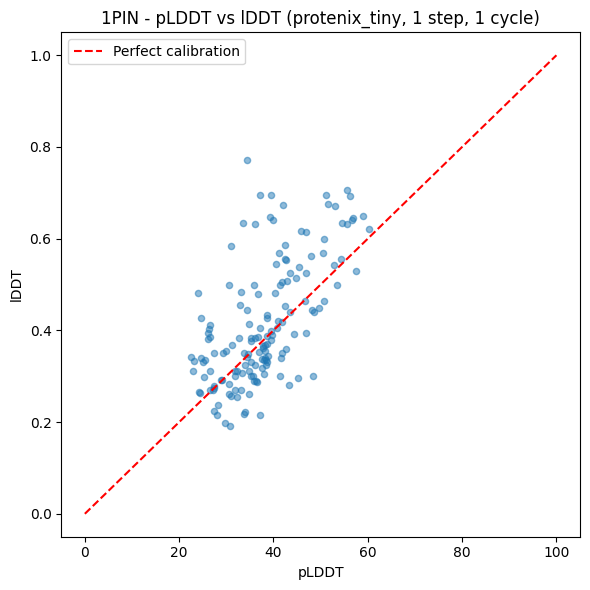

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(plddt_matched, lddt_scores, alpha=0.5, s=20)
plt.plot([0, 100], [0, 1], 'r--', label='Perfect calibration')
plt.xlabel('pLDDT')
plt.ylabel('lDDT')
plt.title('1PIN - pLDDT vs lDDT (protenix_tiny, 1 step, 1 cycle)')
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
from scipy.stats import pearsonr

pearsonr(lddt_scores, plddt_matched)

PearsonRResult(statistic=np.float64(0.631984754401528), pvalue=np.float64(1.9489034252790472e-18))